<a href="https://colab.research.google.com/github/Ricardo-msj/estatistica-descritiva-python/blob/master/analise_cruzada_renda_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Imports**

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
dados = pd.read_csv('dados.csv')

In [39]:
dados.head()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [31]:
round(dados['Cor'].value_counts(normalize= True) * 100, 2)

,proportion
Cor,
8,46.75
2,41.40
4,10.92
0,0.46
6,0.46


In [30]:
frequencia = dados['Cor'].value_counts()


In [34]:
percentual = round(dados['Cor'].value_counts(normalize=True) * 100, 2)

In [35]:
dist_freq_quali = pd.DataFrame({'Frequencia': frequencia, 'Percentual(%)': percentual})

In [36]:
dist_freq_quali

,Frequencia,Percentual(%)
Cor,,
8,35925,46.75
2,31815,41.40
4,8391,10.92
0,357,0.46
6,352,0.46


In [37]:
dist_freq_quali.rename(index= {0:'indigena', 2:'Branca', 4:'Preta', 6:'Amarela', 8:'Parda', 9: 'Sem Declaracao'}, inplace= True)
dist_freq_quali.rename_axis('Cor da Pele', axis = 'columns', inplace=True)
dist_freq_quali.rename_axis(None, axis = 'index', inplace=True)

In [ ]:
dist_freq_quali

Cor da Pele,Frequencia,Percentual(%)
Parda,35925,46.75
Branca,31815,41.40
Preta,8391,10.92
indigena,357,0.46
Amarela,352,0.46


In [5]:
cor = {0:'indigena',
       2:'Branca',
       4:'Preta',
       6:'Amarela',
       8:'Parda',
       9: 'Sem Declaracao'}

sexo = {0:'Masculino',
        1:'Feminino'}

In [45]:
frquencia2 = pd.crosstab(dados.Sexo,
                        dados.Cor,
                        aggfunc= 'mean',
                        values= dados.Renda,
                        )


frquencia2.rename(index=sexo, columns=cor, inplace = True)
frquencia2


Cor,indigena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,1081.710938,2925.744435,1603.861687,4758.251064,1659.577425
Feminino,2464.386139,2109.866750,1134.596400,3027.341880,1176.758516


## Observações

Os resultados da análise cruzada indicam diferenças consistentes na renda média quando considerados
sexo e cor da pele. Em grande parte das categorias, indivíduos do sexo masculino apresentam renda
média superior à feminina. Também se observa que a renda média não é homogênea entre os grupos raciais,
o que sugere a presença de desigualdades estruturais refletidas nos dados.


In [47]:
df_bar = (
    frquencia2
    .reset_index()
    .melt(
        id_vars='Sexo',
        var_name='Cor da pele',
        value_name='Renda média'
    )
)

df_bar


,Sexo,Cor da pele,Renda média
0,Masculino,indigena,1081.710938
1,Feminino,indigena,2464.386139
2,Masculino,Branca,2925.744435
3,Feminino,Branca,2109.866750
4,Masculino,Preta,1603.861687
5,Feminino,Preta,1134.596400
6,Masculino,Amarela,4758.251064
7,Feminino,Amarela,3027.341880
8,Masculino,Parda,1659.577425
9,Feminino,Parda,1176.758516


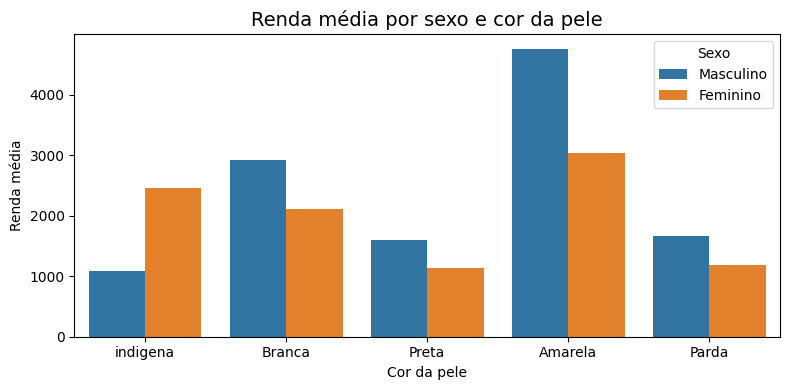

In [48]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=df_bar,
    x='Cor da pele',
    y='Renda média',
    hue='Sexo'
)

plt.title('Renda média por sexo e cor da pele', fontsize=14)
plt.xlabel('Cor da pele')
plt.ylabel('Renda média')
plt.legend(title='Sexo')

plt.tight_layout()
plt.show()


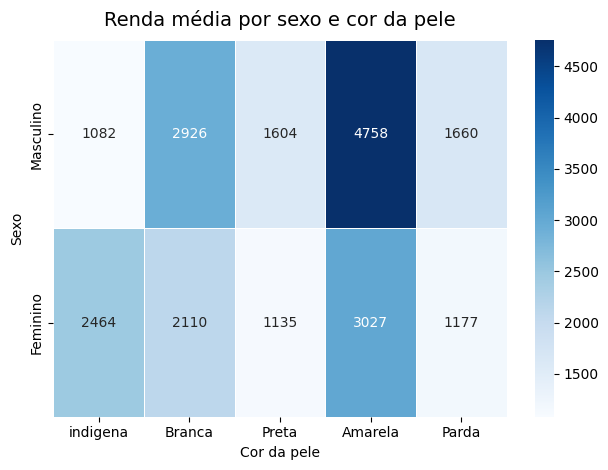

In [28]:
ax = sns.heatmap(frquencia2,
                 annot=True,
                 cmap='Blues',
                 fmt = ".0f",
                 linewidths = 0.5,
                 annot_kws = {"size": 10})

ax.set_title("Renda média por sexo e cor da pele", fontsize=14, pad=10)
ax.set_xlabel("Cor da pele")
ax.set_ylabel("Sexo")

plt.tight_layout()
plt.show()


## Visualização

O mapa de calor permite comparar visualmente a renda média entre os grupos definidos por
sexo e cor da pele. Observa-se que, em grande parte das categorias, os valores associados
ao sexo masculino são superiores aos do sexo feminino. Também se destacam diferenças de
renda média entre os grupos raciais, evidenciadas pela variação de intensidade das cores.
